In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df=pd.read_excel("cgpaPRED.xls")
df.head()

Saving cgpaPRED.xls to cgpaPRED.xls


,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEM 1   379 non-null    float64
 1   SEM 2   379 non-null    float64
 2   SEM 3   379 non-null    float64
 3   SEM 4   379 non-null    float64
 4   SEM 5   379 non-null    float64
dtypes: float64(5)
memory usage: 14.9 KB


,0
SEM 1,0
SEM 2,0
SEM 3,0
SEM 4,0
SEM 5,0


In [5]:
x=df.drop("SEM 5",axis=1)
y=df["SEM 5"]

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_trst=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)

          SEM 1     SEM 2     SEM 3     SEM 4     SEM 5
SEM 1  1.000000  0.976568  0.968651  0.959469  0.986322
SEM 2  0.976568  1.000000  0.980775  0.973422  0.992863
SEM 3  0.968651  0.980775  1.000000  0.978519  0.992036
SEM 4  0.959469  0.973422  0.978519  1.000000  0.987919
SEM 5  0.986322  0.992863  0.992036  0.987919  1.000000


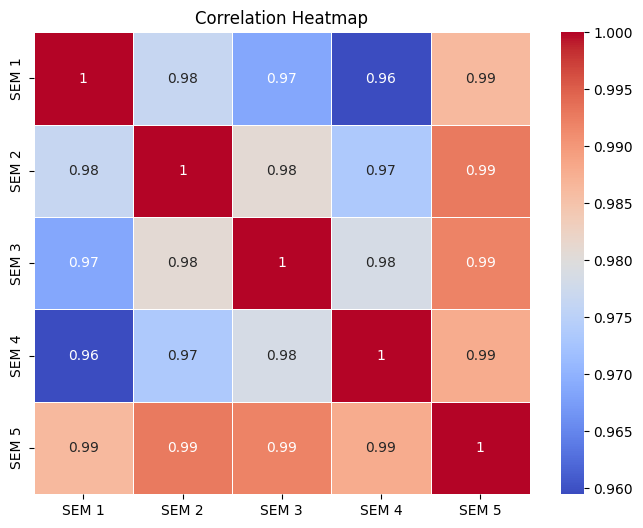

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

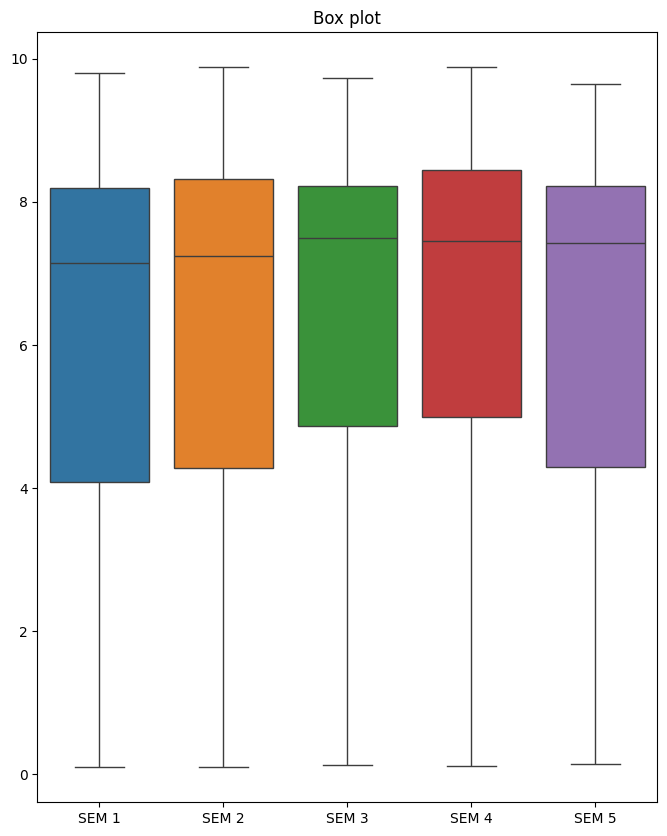

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("cgpaPRED.xls")
plt.figure(figsize=(8,10))
sns.boxplot(data=df[["SEM 1","SEM 2","SEM 3","SEM 4","SEM 5"]])
plt.title("Box plot")
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

Mean Squared Error is: 
0.11749088625729909
Root Mean Squared Error is: 
0.34276943600224785
Mean Absolute Error is: 
0.24539275272591365
R2 Score is: 
0.9887037961166778


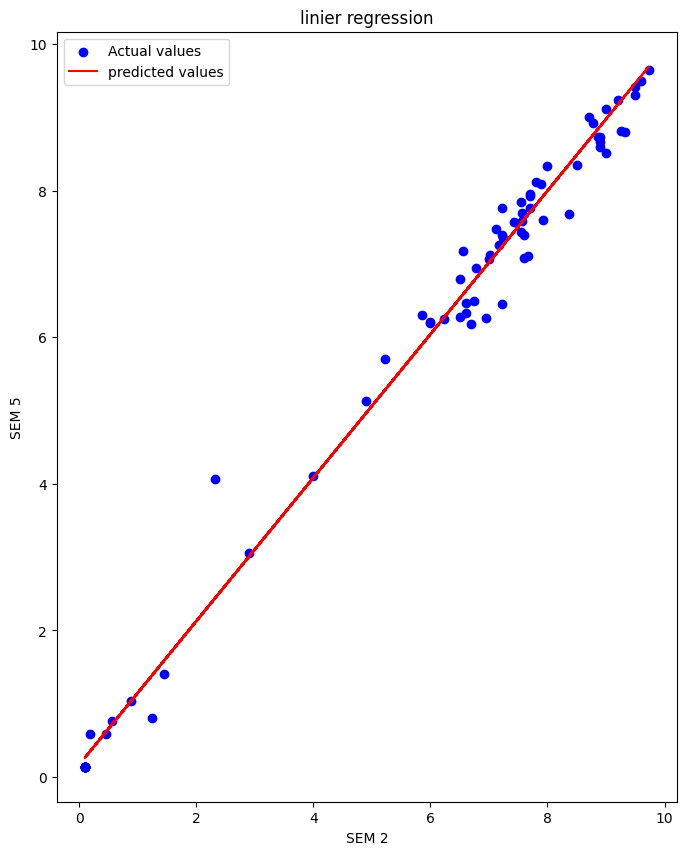

In [15]:
import pandas as pd
corr=df.iloc[:,:4].corrwith(df["SEM 5"])
best_feature = corr.abs().idxmax()
x=df[[best_feature]]
y=df['SEM 5']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error is: ")
print(mse)
ms=mse
rmse=np.sqrt(ms)
print("Root Mean Squared Error is: ")
print(rmse)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error is: ")
print(mae)
r2=r2_score(y_test,y_pred)
print("R2 Score is: ")
print(r2)
plt.figure(figsize=(8,10))
plt.scatter(x_test,y_test,color='blue',label="Actual values")
plt.plot(x_test,y_pred,color="red",label="predicted values")
plt.title("linier regression")
plt.xlabel(best_feature)
plt.ylabel("SEM 5")
plt.legend()
plt.show()

In [ ]:
x=df.drop("SEM 5",axis=1)
y=df["SEM 5"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error is: ")
print(mse)
ms=mse
rmse=np.sqrt(ms)
print("Root Mean Squared Error is: ")
print(rmse)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error is: ")
print(mae)
r2=r2_score(y_test,y_pred)
print("R2 Score is: ")
print(r2)

Mean Squared Error is: 
7.162756055514429e-06
Root Mean Squared Error is: 
0.00267633257565543
Mean Absolute Error is: 
0.0023391696650216596
R2 Score is: 
0.9999993113342205


In [ ]:
sem1=float(input("Enter your sem1 grade: "))
sem2=float(input("Enter your sem2 grade: "))
sem3=float(input("Enter your sem3 grade: "))
sem4=float(input("Enter your sem4 grade: "))
new_data={
    "SEM 1":[sem1],
    "SEM 2":[sem2],
    "SEM 3":[sem3],
    "SEM 4":[sem4]
}
new_df=pd.DataFrame(new_data)
prediction=model.predict(new_df)
print("predicted sem5 mark",np.round(prediction[0],2))

Enter your sem1 grade: 8.91
Enter your sem2 grade: 8.65
Enter your sem3 grade: 8.52
Enter your sem4 grade: 9.05


NameError: name 'model' is not defined